In [85]:
import math, cmath
from itertools import product, groupby, chain
from collections import Counter

# From single particle state to *Bosonic statistics*

Let's consider a single particle in 3D space. This particle is in a potential 

$$V(x,y,z) = \frac{1}{2}x^2 + \frac{1}{2}y^2 + \frac{1}{2}z^2$$

It's total energy $E$ is given by the sum of energies in each direction $x,y,z$ as follows

$$E = E^x + E^y + E^z$$

We want to compute the **single-particle degeneracy** $\mathcal{N}(E)$, that is, the number of
these states with energy $E$.

In [92]:
def naive_degeneracy(max_energy: int) -> list[tuple[int, int, int]]:
    """
    Compute all non-negative integer triples grouped by total energy.

    Parameters
    ----------
    max_energy : int
        Maximum allowed total energy and upper bound for each individual
        quantum number.

    Returns
    -------
    list[tuple[int, int, int]]
        All posible energy states (Ex, Ey, Ez) sorted by total energy.
    """
    # Compute the total ener
    total_energies = sorted(
        product(range(max_energy + 1),
                range(max_energy + 1),
                range(max_energy + 1)),
        key=lambda e: sum(e))
    # Filter for total energy <= max_energy
    energies = filter(
        lambda e: sum(e) <= max_energy,
        total_energies)
    return list(energies)

In [94]:
# naive_single_particle.py
Emax = 4
degeneracies = naive_degeneracy(Emax)

print('  # |  E | Ex | Ey | Ez')
print('------------------------')
for k, energies in enumerate(degeneracies):
    Ex, Ey, Ez = energies
    print(f"{k:3} | {sum(energies):2} | {Ex:2} | {Ey:2} | {Ez:2}")

  # |  E | Ex | Ey | Ez
------------------------
  0 |  0 |  0 |  0 |  0
  1 |  1 |  0 |  0 |  1
  2 |  1 |  0 |  1 |  0
  3 |  1 |  1 |  0 |  0
  4 |  2 |  0 |  0 |  2
  5 |  2 |  0 |  1 |  1
  6 |  2 |  0 |  2 |  0
  7 |  2 |  1 |  0 |  1
  8 |  2 |  1 |  1 |  0
  9 |  2 |  2 |  0 |  0
 10 |  3 |  0 |  0 |  3
 11 |  3 |  0 |  1 |  2
 12 |  3 |  0 |  2 |  1
 13 |  3 |  0 |  3 |  0
 14 |  3 |  1 |  0 |  2
 15 |  3 |  1 |  1 |  1
 16 |  3 |  1 |  2 |  0
 17 |  3 |  2 |  0 |  1
 18 |  3 |  2 |  1 |  0
 19 |  3 |  3 |  0 |  0
 20 |  4 |  0 |  0 |  4
 21 |  4 |  0 |  1 |  3
 22 |  4 |  0 |  2 |  2
 23 |  4 |  0 |  3 |  1
 24 |  4 |  0 |  4 |  0
 25 |  4 |  1 |  0 |  3
 26 |  4 |  1 |  1 |  2
 27 |  4 |  1 |  2 |  1
 28 |  4 |  1 |  3 |  0
 29 |  4 |  2 |  0 |  2
 30 |  4 |  2 |  1 |  1
 31 |  4 |  2 |  2 |  0
 32 |  4 |  3 |  0 |  1
 33 |  4 |  3 |  1 |  0
 34 |  4 |  4 |  0 |  0


The system has **2 degrees of freedom**, meaning that for a given energy state $E$ and choices $E^x, E^y$ the enrgy state of the 3rd direction is fixed $$E^z = E - E^x - E^y$$

For a given choice for $E^x$, the enrgy state $E^y$ can vary fro $0$ to $E - E^x + 1$. Therefore, the total number of configurations $\mathcal{N}(E)$ for total energy $E$ is

$$\begin{aligned}
\mathcal{N}(E) &= \large\sum_{\large E^x = 0}^{E} (E - E^x + 1) \\ \\
&= (E+1) + (E) + (E - 1) + \dots + (1) \\ \\
&= \frac{(E+2)(E+1)}{2}
\end{aligned}$$

We can use a more **systematic** way to compute the number of states with total energy $E$.

$$\begin{aligned}
\mathcal{N}(E) &= \sum_{\large E^x = 0}^{E}\;\sum_{\large E^y = 0}^{E} \; \sum_{\large E^z = 0}^{E} {\large \delta_{E^x+E^y+E^z, E}}
\end{aligned}$$

where $\delta_{k,l} = \delta_{k-l,0}$ is the Kronecker delta function.

## Computation of the sum using the $Z$ transform

The $Z$ transform of the Kronecker delta is 

$$\mathcal{Z}\{\delta_{\large E^x + E^y + E^z - E}\} = z^{-E}$$
therefore, $\delta_{E^x + E^y + E^z - E}$ can be represented by the integral
$$\delta_{E^x + E^y + E^z - E} = \frac{1}{2i\pi}\oint_\gamma dz\, z^{E^x + E^y + E^z - 1} z^{-E}$$

Substituting into the triple sum we get

$$\begin{aligned}
\mathcal{N}(E) &= \sum_{\large E^x = 0}^{E}\;
                  \sum_{\large E^y = 0}^{E}\;
                  \sum_{\large E^z = 0}^{E}\;
                  \frac{1}{2i\pi}\oint_\gamma dz\, z^{E^x + E^y + E^z - 1} z^{-E}\\
\\
               &= \frac{1}{2i\pi}\oint_\gamma dz\, z^{-(E + 1)} \;
                  \Bigg(\sum_{\large E^x = 0}^{E} z^{E^x}\Bigg)\;
                  \Bigg(\sum_{\large E^y = 0}^{E} z^{E^y}\Bigg)\;
                  \Bigg(\sum_{\large E^z = 0}^{E} z^{E^z}\Bigg)\; \\
\\
              &= \frac{1}{2i\pi}\oint_\gamma dz\, z^{-(E + 1)} \;
                 \bigg(\frac{1 - z^{E+1}}{1 - z}\bigg) \;
                 \bigg(\frac{1 - z^{E+1}}{1 - z}\bigg) \;
                 \bigg(\frac{1 - z^{E+1}}{1 - z}\bigg) \; \\
\\
             &= \frac{1}{2i\pi}\oint_\gamma dz\,\frac{z^{-E-1}}{(1-z)^3}\big(1 - z^{E+1}\big)^3
\end{aligned}$$


We can use the fact that $$\frac{1}{(1-z)^3} = \frac{1}{2}\sum_{k=0}^{\infty} (k+2)(k+1)z^k$$ which implies that

$$\mathcal{N}(E) = \frac{1}{4i\pi}\oint_\gamma dz\,\big(1 - z^{E+1}\big)^3 \bigg[\sum_{k=0}^\infty (k+2)(k+1)z^{k-E-1}\bigg]$$

By using the residue theoreme, the value of the integral is $$\mathcal{N}(E) = \frac{1}{4i\pi} 2i\pi \;a_{-1}$$

where $a_{-1}$ is the coefficent of the tem $z^{-1}$ of the Laurent expansion of the integral. We want $k-E-1 = -1$ therefore $k = E$ and $$\boxed{\mathcal{N}(E) = \frac{(E+2)(E+1)}{2}}$$

## Bosons

**For concreteness, we shall ﬁrst work on what we call the ﬁve-boson bounded trap model, which consists of ﬁve bosons in the harmonic trap**, with a cutoﬀ on the single-particle energies, namely
$$E_\sigma \leq 4$$

$$
\bigg\{\begin{array}{l}
\text{five-particle} \\
\quad\text{state}
\end{array}\bigg\} = \sigma_0, \sigma_1, \dots, \sigma_4
$$

where $\sigma_i = 0,1,\dots,34$

# Enumeration and integration for bosons

There are many configurations with the same enaergy:

$$
\begin{bmatrix}
    \sigma_0 \gets 34\\
    \sigma_1 \gets 5\\
    \sigma_2 \gets 8\\
    \sigma_3 \gets 0\\
    \sigma_4 \gets 11\\
\end{bmatrix} \quad \text{same as} \quad
\begin{bmatrix}
    \sigma_0 \gets 8\\
    \sigma_1 \gets 5\\
    \sigma_2 \gets 34\\
    \sigma_3 \gets 0\\
    \sigma_4 \gets 11\\
\end{bmatrix} \quad \text{same as} \quad
\begin{bmatrix}
    \sigma_0 \gets 0\\
    \sigma_1 \gets 5\\
    \sigma_2 \gets 8\\
    \sigma_3 \gets 11\\
    \sigma_4 \gets 34\\
\end{bmatrix}
$$

To avoid overcounting we choose configurations where $$\sigma_0 \leq \sigma_1 \leq \dots \leq \sigma_4$$

The pertiion function is as follows

$$Z(\beta) = \sum_{\sigma_0\leq\dots\leq\sigma_{N-1}} {\large e^{-\beta\,E(\sigma_0,\dots,\sigma_{N-1})}}$$

The average energy and the average condensate fraction are defined as
$$\begin{aligned}
\langle E \rangle &= \frac{1}{Z_\text{btm}} \sum_{\sigma_0\leq\dots\leq\sigma_{N-1}} E(\sigma_0,\dots,\sigma_{N-1}) \;{\large e^{-\beta\,E(\sigma_0,\dots,\sigma_{N-1})}}\\
\\
\langle N_0 \rangle / N &= \frac{1}{N\, Z_\text{btm}} \sum_{\sigma_0\leq\dots\leq\sigma_{N-1}} |\{\sigma_i = 0\}| \;{\large e^{-\beta\,E(\sigma_0,\dots,\sigma_{N-1})}}\\ \\
\end{aligned}$$

In [42]:
def naive_bosons(beta: float,
                 n_bosons: int = 5,
                 max_energy: int = 4,
                ) -> tuple[float, float, float]:
    """
    Compute thermodynamic averages for a naive non-interacting boson model.

    Parameters
    ----------
    beta : float
        Inverse temperature (β = 1 / kT in natural units).
    n_bosons : int, optional
        Number of indistinguishable bosons in the system (default is 5).
    max_energy : int, optional
        Maximum single-particle energy cutoff used to construct the
        discrete energy spectrum (default is 4).

    Returns
    -------
    tuple[float, float, float]
        A tuple containing:
        - Z : float
            Partition function.
        - avg_E : float
            Thermal expectation value of total energy ⟨E⟩.
        - avg_N0 : float
            Thermal expectation value of the number of bosons in the
            ground state.
    """
    # Max state -> energy of that state
    energies = [sum(e) for e in naive_degeneracy(max_energy)]
    max_state = len(energies)
    # Compute all valid states
    n_states = 0
    Zbtm, avg_E, avg_N0 = 0.0, 0.0, 0.0
    stack = [[s] for s in range(max_state)]
    while stack != []:
        state = stack.pop()
        if len(state) == n_bosons:
            total_energy = sum(energies[s] for s in state)
            N0 = state.count(0)
            w = math.exp(-beta * total_energy)
            Zbtm += w
            avg_E += total_energy * w
            avg_N0 += N0 * w
            continue
        for s in range(state[-1], max_state):
            stack.append(state + [s])
    # Return results
    return Zbtm, (avg_E / Zbtm), (avg_N0 / Zbtm)

In [40]:
temperatures = [k / 10.0 for k in range(1, 11)] # 0.1 -> 1.0
n_bosons = 5

print('+-------+-------+-------+--------+')
print('|  Temp |  Zbtm | <E>/N | <N0>/N |')
print('+-------+-------+-------+--------+')
for T in temperatures:
    beta = 1 / T
    Zbtm, avg_E, avg_N0 = naive_bosons(beta, n_bosons=n_bosons)
    print(f"|{T:6.3f} |{Zbtm:6.3f} |{avg_E/n_bosons:6.3f} | {avg_N0/n_bosons:4.3f}  |")
print('+--------------------------------+')

+-------+-------+-------+--------+
|  Temp |  Zbtm | <E>/N | <N0>/N |
+-------+-------+-------+--------+
| 0.100 | 1.000 | 0.000 | 1.000  |
| 0.200 | 1.021 | 0.004 | 0.996  |
| 0.300 | 1.124 | 0.026 | 0.976  |
| 0.400 | 1.355 | 0.074 | 0.937  |
| 0.500 | 1.780 | 0.157 | 0.878  |
| 0.600 | 2.536 | 0.282 | 0.801  |
| 0.700 | 3.873 | 0.444 | 0.711  |
| 0.800 | 6.237 | 0.634 | 0.616  |
| 0.900 |10.359 | 0.835 | 0.526  |
| 1.000 |17.373 | 1.031 | 0.447  |
+--------------------------------+


For a system of $N$ particles we can define the **occupation numbers** $n_\sigma$ where

$$n_\sigma = \text{\# bosons in state }\sigma$$

The total energy for a configuration is 
$$E_\text{tot} = n_0 E_0 + n_1 E_1 + \dots$$

The partition function is geven by

$$Z_N(\beta) = \int_{-\pi}^\pi \frac{d\lambda}{2\pi}\,{\large e^{-iN\lambda} \prod_{E=0}^{E_\max}} \big[f_E(\beta,\lambda) \big]^{\mathcal{N}(E)}$$

where
$$\begin{aligned}
f_E(\beta, \lambda) &= \frac{1-\exp[i(N+1)\lambda]}{1 - \exp(i\lambda)}, \quad E=0\\
\\
f_E(\beta, \lambda) &= \frac{1}{1 - \exp(-\beta E + i\lambda)}, \quad E>0\\
\end{aligned}$$

In [87]:
def canonic_bosons(
    n_bosons: int,
    beta: float,
    single_particle_states: list[tuple[int, ...]],
    dlambda: float,
    tol: float = 1e-12
) -> Tuple[float, float, float]:
    """
    Canonical partition function, mean energy, and mean ground‑state occupation
    for n_bosons identical bosons.

    Parameters
    ----------
    n_bosons : int
        Total number of bosons.
    beta : float
        Inverse temperature (1/(k_B T)).
    single_particle_states : List[Tuple[int, ...]]
        Each state is a tuple of quantum numbers; energy = sum(quantum numbers).
    dlambda : float
        Step size for the Riemann sum over λ in [-π, π). The actual step is
        adjusted to exactly cover the interval.
    tol : float, optional
        If |λ| < tol, use analytic limits for the ground‑state terms to avoid
        division by zero.  Default is 1e-12.

    Returns
    -------
    Tuple[float, float, float]
        (Z, mean_energy, mean_N0)
    """
    # ----- Build degeneracy dictionary -----
    degeneracy = Counter()
    for state in single_particle_states:
        E = sum(state)
        degeneracy[E] += 1
    max_energy = max(degeneracy.keys()) if degeneracy else 0
    degeneracies = [degeneracy.get(E, 0) for E in range(max_energy + 1)]

    # ----- Riemann sum over λ -----
    nsteps = int(round(2 * math.pi / dlambda))
    dlambda = 2 * math.pi / nsteps

    Z = 0.0
    mean_E_num = 0.0
    mean_N0_num = 0.0

    for i in range(nsteps):
        lam = -math.pi + (i + 0.5) * dlambda

        # ----- Ground state: use analytic limits when λ is very small -----
        if abs(lam) < tol:
            # Limits: f0 → N+1,  N0_lam → N/2
            f0 = n_bosons + 1.0
            N0_lam = n_bosons / 2.0
        else:
            zl = 1j * lam
            exp_i_lam = cmath.exp(zl)
            exp_i_lam_N1 = cmath.exp(zl * (n_bosons + 1))

            f0 = (1.0 - exp_i_lam_N1) / (1.0 - exp_i_lam)
            term1 = -(n_bosons + 1) * exp_i_lam_N1 / (1.0 - exp_i_lam_N1)
            term2 = exp_i_lam / (1.0 - exp_i_lam)
            N0_lam = term1 + term2

        prod = f0
        sum_E = 0.0 + 0.0j

        # ----- Excited states (E = 1 .. max_energy) -----
        for E in range(1, max_energy + 1):
            degen = degeneracies[E]
            if degen == 0:
                continue
            exp_term = cmath.exp(-beta * E + 1j * lam)
            fE = 1.0 / (1.0 - exp_term)
            prod *= fE ** degen
            sum_E += degen * E * (exp_term / (1.0 - exp_term))

        factor = cmath.exp(-1j * n_bosons * lam)

        integrand_Z = prod * factor
        integrand_E = sum_E * prod * factor
        integrand_N0 = N0_lam * prod * factor

        weight = dlambda / (2.0 * math.pi)
        Z += integrand_Z.real * weight
        mean_E_num += integrand_E.real * weight
        mean_N0_num += integrand_N0.real * weight

    mean_energy = mean_E_num / Z
    mean_N0 = mean_N0_num / Z
    return Z, mean_energy, mean_N0

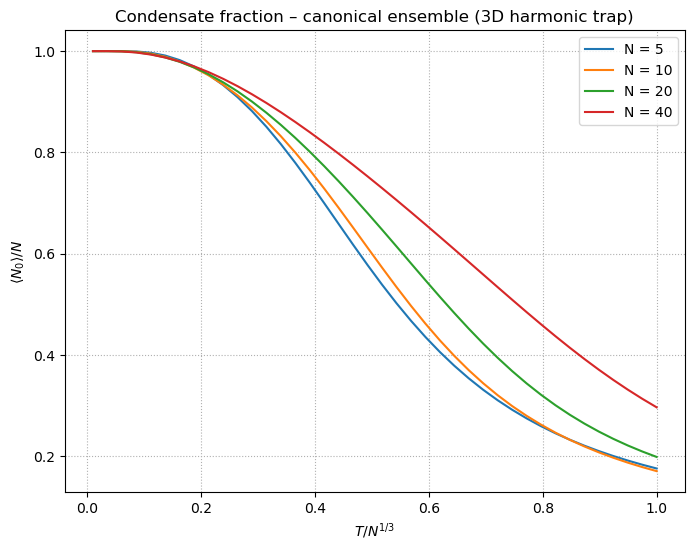

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# IMPORTANT: The function canonic_bosons must already be defined.
# It should accept (n_bosons, beta, single_particle_states, dlambda)
# and return (Z, mean_E, mean_N0). The code below uses it.
# ----------------------------------------------------------------------

# Generate single‑particle states for 3D isotropic harmonic oscillator
# (energy E = i+j+k, up to some cutoff Emax)
Emax = 4                    # sufficiently large cutoff
states = naive_degeneracy(Emax)

# Parameters
N_values = [5, 10, 20, 40]
scaled_T = np.linspace(0.01, 1.0, 40)     # T / N^{1/3}
dlambda = 0.03                            # step for Riemann sum

plt.figure(figsize=(8,6))
for N in N_values:
    frac = []
    T_scale = N ** (1/3)
    for T_sc in scaled_T:
        if T_sc == 0:
            frac.append(1.0)
        else:
            T = T_sc * T_scale
            beta = 1.0 / T
            _, _, mean_N0 = canonic_bosons(N, beta, states, dlambda)
            frac.append(mean_N0 / N)
    plt.plot(scaled_T, frac, '-', label=f'N = {N}')

plt.xlabel(r'$T / N^{1/3}$')
plt.ylabel(r'$\langle N_0 \rangle / N$')
plt.title('Condensate fraction – canonical ensemble (3D harmonic trap)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()